# Distance-CRP

> Reveal semantic contiguity in recall transitions using embedding distances.

The distance-conditioned response probability (Distance-CRP) replaces serial lags with semantic or spatial distances supplied by the caller. Each recall transition is assigned to a distance bin and availability is tallied as the set of bins containing at least one unrecalled item at the moment of choice.

$$\text{CRP}(d) = \frac{\text{actual transitions in distance bin } d}{\text{available transitions in distance bin } d}$$

Downward-sloping curves indicate a semantic contiguity effect: participants preferentially transition to items that are semantically similar to the just-recalled item.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import warnings
from jaxcmr.analyses.distcrp import plot_dist_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listtype'] == -1"
features_path = "data/peers-all-mpnet-base-v2.npy"
bin_step = 0.05
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)
features = np.load(os.path.join(project_root, features_path)).astype(np.float32)

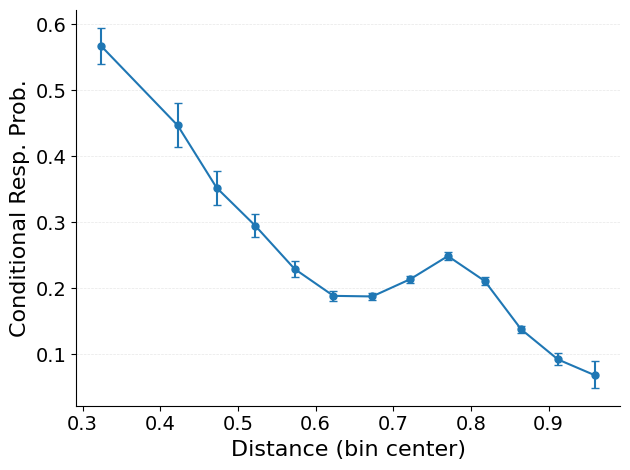

In [4]:
plot_dist_crp(
    datasets=data,
    trial_masks=trial_mask,
    features=features,
    bin_step=bin_step,
    confidence_level=confidence_level,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The x-axis shows cosine-distance bins and the y-axis shows the conditional probability of transitioning to an item in that distance bin. Key patterns:

- **Downward slope**: higher transition probabilities for semantically similar items (low distance) indicate a semantic contiguity effect.
- **Flat curve**: transitions are unrelated to semantic distance, suggesting semantic similarity does not drive recall organization.
- **Bin width**: controlled by `bin_step`; smaller values give finer resolution but noisier estimates.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `features_path` — path to a numpy file containing word embeddings (shape: `[word_count, features_count]`).
- `bin_step` — width of each cosine-distance bin.
- `confidence_level` — confidence level for subject-wise error bars.

For categorical distance analysis (same vs. different category), see the Category-CRP template which uses `plot_cat_crp`.